Notebook 04 - ML Model: Naive Bayes
NLP Assignment - Fake News Detection
Person 3: N.A.Matheesha Desaman (CIT-24-01-0435)

# ML Model: Naive Bayes with BERT Embeddings
**Why Naive Bayes?** It's fast, interpretable, and surprisingly effective
for text classification. Despite its "naive" independence assumption,
it performs well when features are meaningful — and BERT embeddings
are very meaningful!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
X = np.load('../data/bert_embeddings_X.npy')
y = np.load('../data/bert_labels_y.npy')

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label distribution:", np.unique(y, return_counts=True))

X shape: (2000, 768)
y shape: (2000,)
Label distribution: (array([0, 1]), array([ 960, 1040]))


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1600, 768)
Test set: (400, 768)


In [4]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("✅ Naive Bayes model trained!")

✅ Naive Bayes model trained!


In [5]:
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("=" * 40)
print("NAIVE BAYES RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

NAIVE BAYES RESULTS
Accuracy:  0.8075
Precision: 0.7835
Recall:    0.8702
F1-Score:  0.8246
ROC-AUC:   0.8619

Classification Report:
              precision    recall  f1-score   support

        Fake       0.84      0.74      0.79       192
        Real       0.78      0.87      0.82       208

    accuracy                           0.81       400
   macro avg       0.81      0.80      0.81       400
weighted avg       0.81      0.81      0.81       400



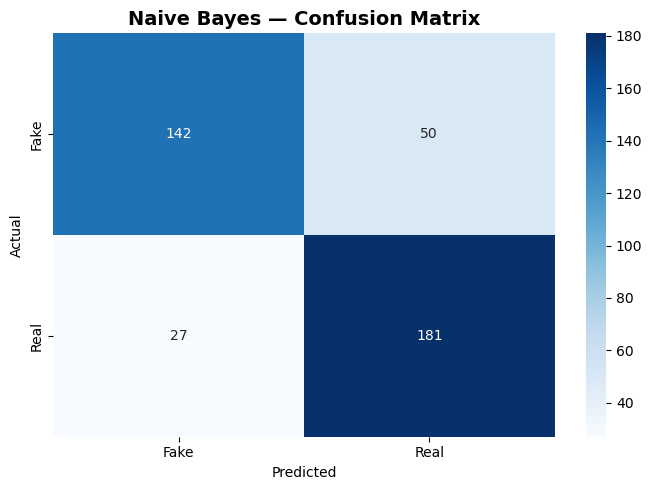

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Naive Bayes — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/05_nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

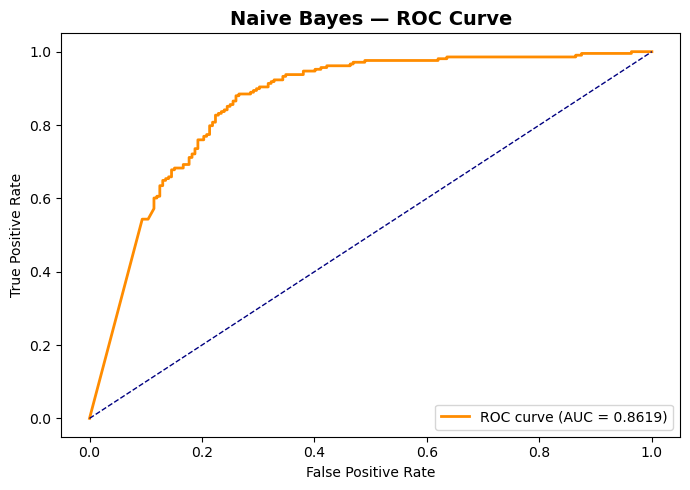

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes — ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../screenshots/06_nb_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of Naive Bayes Results

| Metric | Score |
|--------|-------|
| Accuracy | 0.8075 |
| Precision | 0.7835 |
| F1-Score | 0.8246 |
| ROC-AUC | 0.8619 |

**Observation:** Naive Bayes with BERT embeddings captures semantic meaning
better than traditional Bag-of-Words approaches. The model is fast to train
and easy to interpret, making it ideal for baseline comparisons.